In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from random import sample
import warnings
import time

sns.set(color_codes=True)

from lifelines.plotting import plot_lifetimes      # Lifeline package for the Survival Analysis
%pylab inline
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

warnings.filterwarnings('ignore')
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)

2020-01-05 00:00:00
2020-01-05 00:00:00


In [4]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


In [5]:
imports()

What is the source of the MOVEMENT data? (1=internet, 2=home Mac, 3=office Windows)2
What type of import is it? (1 = initial (only cases and movement), 2 = initial (full), 3 = data by week, 4 = merged datasets, 5 = only cases)4

../../02 data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185852 entries, 0 to 1185851
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   date             1185852 non-null  datetime64[ns]
 1   GADM_GID_2       1185852 non-null  object        
 2   mun_name         1185852 non-null  object        
 3   movement_change  1185852 non-null  float64       
 4   stay_put         1185852 non-null  float64       
 5   epi_week         1185852 non-null  object        
 6   ibge_code        1185852 non-null  int64         
 7   pop_2020         1185852 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 72.4+ MB

++++++++++++

In [7]:
cases_by_epi_week_merged_clean = clean_cases_by_epi_week(cases_by_epi_week_merged)
cases_by_epi_week_merged_clean

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
0,1100015,2020.18,1,0,1,0,22945.0,2020.18,4.36,0.00,2020-05-10
1,1100015,2020.19,8,0,0,0,22945.0,2020.19,34.87,0.00,2020-05-17
2,1100015,2020.20,7,0,0,0,22945.0,2020.20,30.51,0.00,2020-05-24
3,1100015,2020.21,13,0,3,0,22945.0,2020.21,56.66,0.00,2020-05-31
4,1100015,2020.22,21,0,-1,0,22945.0,2020.22,91.52,0.00,2020-06-07
...,...,...,...,...,...,...,...,...,...,...,...
308030,5300108,2021.17,2316597,49512,6624,263,3015268.0,2021.17,76828.89,16420.43,2021-05-02
308031,5300108,2021.18,2358003,51165,5390,237,3015268.0,2021.18,78202.10,16968.64,2021-05-09
308032,5300108,2021.19,2396055,52654,5311,185,3015268.0,2021.19,79464.08,17462.46,2021-05-16
308033,5300108,2021.20,2433365,53799,5337,142,3015268.0,2021.20,80701.45,17842.20,2021-05-23


---

code for one city, generates index from total deaths in that city

In [8]:
city = '1100015'
cases_one_city = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city]
events_one_city = events_cities(cases_one_city)
events_one_city 

,event,week
0,1.0,11.0
1,1.0,13.0
2,1.0,14.0
3,1.0,15.0
4,1.0,16.0
...,...,...
56,1.0,55.0
57,1.0,55.0
58,1.0,55.0
59,1.0,55.0


In [10]:
events_rs = events_uf('43')
events_rs

event  week
4300034 0     1.0  38.0
        1     1.0  38.0
        2     1.0  39.0
        3     1.0  40.0
4300059 0     1.0  17.0
...           ...   ...
4323804 35    1.0  52.0
        36    1.0  52.0
        37    1.0  54.0
        38    1.0  55.0
        39    1.0  56.0

[27640 rows x 2 columns]

getting the dataframes and plotting for SP, RJ and POA

In [ ]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'

In [26]:
#preparing dataset for PA
city = '4314902'
cases_pa = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city]
events_pa = events_cities(cases_pa)
events_pa

,event,week
0,1.0,2.0
1,1.0,2.0
2,1.0,3.0
3,1.0,3.0
4,1.0,4.0
...,...,...
4703,1.0,63.0
4704,1.0,63.0
4705,1.0,63.0
4706,1.0,63.0


In [27]:
#Checking if all deaths are accounted for
city = '4314902'
cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city].new_deaths.sum()

4708

In [28]:
#preparing dataset for RJ
city = '3304557'
cases_rj = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city]
events_rj = events_cities(cases_rj)
events_rj

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
25928,1.0,64.0
25929,1.0,64.0
25930,1.0,64.0
25931,1.0,64.0


In [29]:
#Checking if all deaths are accounted for
cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city].new_deaths.sum()

25933

In [30]:
#preparing dataset for SP
city = '3550308'
cases_sp = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city]
events_sp = events_cities(cases_sp)
events_sp

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
29875,1.0,65.0
29876,1.0,65.0
29877,1.0,65.0
29878,1.0,65.0


In [31]:
#Checking if all deaths are accounted for
cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == city].new_deaths.sum()

29880

In [35]:
dict_events_cities = {}
dict_events_cities['4314902'] = events_cities(cases_pa)
dict_events_cities['3304557'] = events_cities(cases_rj)
dict_events_cities['3550308'] = events_cities(cases_sp)

{'4314902':       event  week
 0       1.0   2.0
 1       1.0   2.0
 2       1.0   3.0
 3       1.0   3.0
 4       1.0   4.0
 ...     ...   ...
 4703    1.0  63.0
 4704    1.0  63.0
 4705    1.0  63.0
 4706    1.0  63.0
 4707    1.0  63.0
 
 [4708 rows x 2 columns],
 '3304557':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 25928    1.0  64.0
 25929    1.0  64.0
 25930    1.0  64.0
 25931    1.0  64.0
 25932    1.0  64.0
 
 [25933 rows x 2 columns],
 '3550308':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 29875    1.0  65.0
 29876    1.0  65.0
 29877    1.0  65.0
 29878    1.0  65.0
 29879    1.0  65.0
 
 [29880 rows x 2 columns]}

In [37]:
df_events_cities = pd.concat(dict_events_cities)
df_events_cities

event  week
4314902 0        1.0   2.0
        1        1.0   2.0
        2        1.0   3.0
        3        1.0   3.0
        4        1.0   4.0
...              ...   ...
3550308 29875    1.0  65.0
        29876    1.0  65.0
        29877    1.0  65.0
        29878    1.0  65.0
        29879    1.0  65.0

[60521 rows x 2 columns]

In [48]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


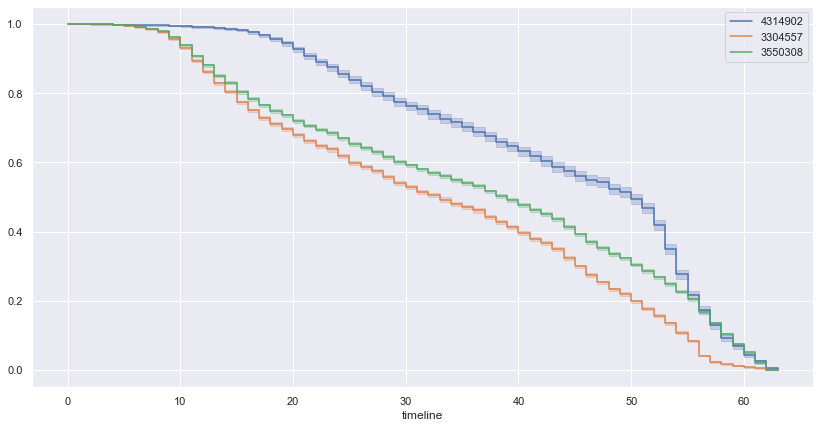

In [50]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'
cities_list = ['4314902', '3304557','3550308'] 
kmf = plot_kmf(df_events_cities,cities_list)

In [54]:
kmf.median_survival_time_

39.0